# Helmholtz & Anti-Helmholtz Coil Simulation

# About
The following script generates a FEMM model, solves it, conducts additional calculations, and extracts data for axisymmetric magnetostatic problems.

# Prerequisites
- Windows...
- Python 3.9 (https://www.python.org/downloads/release/python-390/). I suggest the Miniconda version (https://docs.conda.io/projects/miniconda/en/latest/miniconda-other-installer-links.html.
- Jupyter Notebooks (https://jupyter.org/install)

# Setup
1. Download FEMM (https://www.femm.info/wiki/HomePage)
2. pip install pyfemm
* If you have MacOS or Linux refer to the manual (https://www.femm.info/wiki/pyFEMM/manual.pdf)

# Resources
- FEMM Official Documentation (https://www.femm.info/wiki/Documentation/)

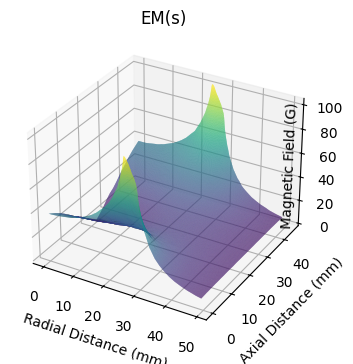

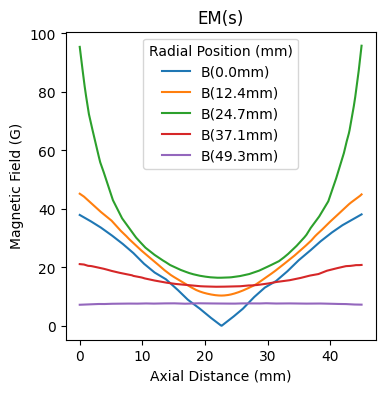

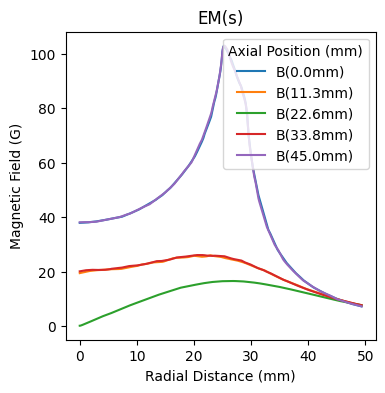

Current: 1 A
Wire Gauge: 22 AWG
Number of Turns: 200
Turns/Layer: 10
Number of Layers: 21
Wire Length/Coil: 33742.1 mm
EM Thickness: 10.6 mm
EM Inner Radius: 25 mm
EM Outer Radius: 29.3 mm
EM separation: 45 mm
Average Radial Gradient is 32.41 G/cm
Average Axial Gradient is 16.85 G/cm
Resistance/Coil: 2.96 Ω
Power Loss/Coil: 2.96 W
Voltage Requirement/Coil: 2.96 V
Inductance (Top Coil): 2.83 mH
Inductance (Bottom Coil): 2.83 mH
No loss, wire heats 465.59°C in 3600 seconds


'\nclose\n'

In [1]:
""" 
Kostubh Agarwal
"""
import femm
import matplotlib.pyplot as plt
import numpy as np

"""
wire specs
- https://mwswire.com/wp-content/uploads/2016/10/Copper-Magnet-Wire-Data.pdf
"""
wire_d = 0.5 #22 AWG, diameter (mm)
wire_c = 0.385 #specific heat (J/g°C)
wire_p = 1.72e-8 #resistivity (Ω·m)
wire_ds = 8.96 #density (g/cm³)

"""
coil specs
https://production-solution.com/coil-calculator.htm 

^cross-sectional area refers to average area enclosed by the coil.

verify with calculator above it's a good sanity check
"""
bobbin_l = 5.3 * 2 #bobbin length (mm)
bobbin_r = 25 #bobbin radius (mm)
coil_n = 100 * 2 #number of turns
num_layer = int(bobbin_l / wire_d)  # How many turns fit along bobbin length
turns_layer = int(np.ceil(coil_n / num_layer))  # Total layers needed
coil_r = bobbin_r + (turns_layer * wire_d * np.sqrt(3)/2)  # Hexagonal packing (mm)
packing_f = 0.9069 #packing factor for hexagonal packing
coil_cs = coil_n * (wire_d/2)**2 * np.pi * packing_f  # cross-sectional area (mm²)
wire_length = 0.0
for layer in range(turns_layer):  # Loop through each layer
    current_radius = bobbin_r + (layer * wire_d * np.sqrt(3)/2)  # Hex packing (mm)
    turns_in_layer = min(num_layer, coil_n - layer * num_layer)  # Handle partial last layer
    wire_length += turns_in_layer * (2 * np.pi * current_radius)  # Sum wire length (mm)
wire_length *= 1e-3  # Convert mm to meters for resistivity calculation
sep = 45 #distance of em's (converted from cm to mm)

"""
data analysis
"""
num = 400 #number of datapoints pulled from simulation, 400 is suggested, for code development 50 is sufficient
num_int = 5 #number of intervals for the 2D plots for axial and radial distances in graphs
intervals = np.arange(5) * int(num / (num_int - 1))
intervals[-1] = num - 1
# intervals = [0] #if you just want to plot a singular axial and radial distance
plot_r = coil_r + 20 #defines plotted area (mm)

"""
simulation paramaters
"""
precision = 1e-8 #solver precision
label_tol = 1e-2 #label offset, places label inside shape (mm)
bound_r = 1.25 * max(coil_r, sep) #boundary radius (mm)
i = 1 #current (A)

"""
initialization
"""
femm.openfemm()
femm.newdocument(0)

"""
problem definition

magnetostatic; units of measure; axisymmetric; 
precision for the linear solver; a placeholder for 
the depth dimension; angle constraint of 30 degrees;
"""
femm.mi_probdef(0, 'millimeters', 'axi', precision, 0, 30)

"""
setup - materials
"""
#air
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0)
femm.mi_addblocklabel(coil_r+label_tol, label_tol)
femm.mi_selectlabel(coil_r+label_tol, label_tol)
femm.mi_setblockprop('Air', 1, 0, '<None>', 0, 0, 0)
femm.mi_clearselected()

"""
setup - physical
"""
#coil (top)
femm.mi_drawrectangle(bobbin_r, sep/2, coil_r, sep/2+bobbin_l)
femm.mi_addmaterial('Coil', 1, 1, 0, 0, 58, 1, 3, 0, 0, 1, 1.0239)
femm.mi_addblocklabel(bobbin_r+label_tol, sep/2+label_tol)
femm.mi_selectlabel(bobbin_r+label_tol, sep/2+label_tol)
femm.mi_addcircprop('icoil', i, 1) #defines direction of current (- into page, + out of page), i defines magnitude of current in the individual coil
femm.mi_setblockprop('Coil', 1, 0, 'icoil', 0, 0, coil_n)
femm.mi_clearselected()

#coil (bottom)
femm.mi_drawrectangle(bobbin_r, -sep/2, coil_r, -sep/2-bobbin_l)
femm.mi_addmaterial('Coil', 1, 1, 0, 0, 58, 1, 3, 0, 0, 1, 1.0239)
femm.mi_addblocklabel(bobbin_r+label_tol, -sep/2-label_tol)
femm.mi_selectlabel(bobbin_r+label_tol, -sep/2-label_tol)
femm.mi_addcircprop('ocoil', -i, 1) #defines direction of current (- into page, + out of page), i defines magnitude of current in the individual coil
femm.mi_setblockprop('Coil', 1, 0, 'ocoil', 0, 0, coil_n)
femm.mi_clearselected()

"""
dirichlet BC (IABC)
"""
femm.mi_makeABC(7, bound_r, 0, 0, 0) #Defines and Improvised Asymptotic Boundary Condition)
    
"""
save file
"""
femm.mi_zoomnatural()
femm.mi_saveas('electro_mag_sim.fem')

"""
mesh and solve
"""
femm.mi_analyze()
femm.mi_loadsolution()

"""
efficiency calculations
"""
wire_r = wire_d / 2 #wire radius (mm)
wire_area = (wire_r ** 2) * np.pi #wire cross-sectional area (mm²)
resistance = wire_p * (wire_length) / (wire_area*1e-6) #resistance (Ω)
wire_m = wire_length * (wire_area*1e-6) * 1e6 * wire_ds #mass of wire (g)
power = i ** 2 * resistance #power loss (W)
voltage = i * resistance #voltage required (V)

"""
inductance calculations
"""
# Calculate magnetic energy using FEMM's circuit properties
# Get circuit properties for both coils
circ_props_top = femm.mo_getcircuitproperties('icoil')  # returns [current, volts, flux_linkage]
circ_props_bottom = femm.mo_getcircuitproperties('ocoil')  # returns [current, volts, flux_linkage]

# Extract flux linkage (in Weber-turns)
flux_linkage_top = circ_props_top[2]
flux_linkage_bottom = circ_props_bottom[2]

# Calculate inductance: L = flux_linkage / current (Henry)
# For anti-Helmholtz configuration, coils are in series with opposite current
inductance_top = abs(flux_linkage_top / i)  # Self-inductance of top coil (H)
inductance_bottom = abs(flux_linkage_bottom / (-i))  # Self-inductance of bottom coil (H)

# Total inductance for series configuration with mutual coupling included
# The flux linkage already accounts for mutual inductance effects
total_inductance = (abs(flux_linkage_top) + abs(flux_linkage_bottom)) / i  # Total inductance (H)

"""
heat generation, assuming no dissipation
"""
t_s = 3600  # Time (s)
dT = power * t_s / (wire_m * wire_c) #delta Temp (°C)

"""
initialize arrays & load data
"""
r = np.linspace(0, plot_r, num) #initializing domain (mm)
z = np.linspace(0, sep, num) #initializing range (mm)
B = np.zeros((num, num)) #initializing flux array (T)

for a in range(0, num):
    for b in range(0, num):
        s, t = femm.mo_getb(r[a], z[b] - sep/2)
        B[a, b] = np.sqrt(s ** 2 + t ** 2) #Tesla

"""
max gradient calcs
"""
loc_r = 0 #defines radial position
loc_z = 0 #defines axial position
dr, dz = r[1]-r[0], z[1]-z[0]  # mm spacing
m_dr = np.mean(np.abs(np.gradient(B[:,0], dr))*1e5)
m_dz = np.mean(np.abs(np.gradient(B[0,:], dz))*1e5)

"""
plots
"""
# 3D field plot
ax = plt.figure(figsize=(4,4)).add_subplot(111, projection='3d') #3d plot
Z, R = np.meshgrid(z, r)
ax.plot_surface(R, Z, B*1e4, rstride=1, cstride=1, cmap='viridis', edgecolor='none') #Convert to G
ax.set_title('EM(s)')
ax.set_xlabel("Radial Distance (mm)")
ax.set_ylabel("Axial Distance (mm)")
ax.set_zlabel("Magnetic Field (G)")
ax.zaxis.labelpad = -26

# axial field plot
plt.figure(figsize=(4,4))  
for ir in intervals:
    r_data = z  # axial distance
    z_data = B[ir, :] * 1e4  # convert to G
    label = f'B({r[ir]:.1f}mm)'
    plt.plot(r_data, z_data, label=label)
plt.xlabel('Axial Distance (mm)')
plt.ylabel('Magnetic Field (G)')
plt.title('EM(s)')
legend = plt.legend()
legend.set_title('Radial Position (mm)')
plt.show()

# radial field plot
plt.figure(figsize=(4,4)) 
for iz in intervals:
    r_data = r  # radial distance
    z_data = B[:, iz] * 1e4  # convert to G
    label = f'B({z[iz]:.1f}mm)'
    plt.plot(r_data, z_data, label=label)
plt.xlabel('Radial Distance (mm)')
plt.ylabel('Magnetic Field (G)')
plt.title('EM(s)')
legend = plt.legend()
legend.set_title('Axial Position (mm)')
plt.show()

"""
output
"""
print(f"Current: {i} A")
print(f"Wire Gauge: 22 AWG")
print(f"Number of Turns: {coil_n}")
print(f"Turns/Layer: {turns_layer}")
print(f"Number of Layers: {num_layer}")
print(f"Wire Length/Coil: {wire_length*1e3:.1f} mm")
print(f"EM Thickness: {bobbin_l} mm")
print(f"EM Inner Radius: {bobbin_r} mm")
print(f"EM Outer Radius: {coil_r:.1f} mm")
print(f"EM separation: {sep} mm")
print(f"Average Radial Gradient is {m_dr:.2f} G/cm")
print(f"Average Axial Gradient is {m_dz:.2f} G/cm")
print(f"Resistance/Coil: {resistance:.2f} Ω")
print(f"Power Loss/Coil: {power:.2f} W")
print(f"Voltage Requirement/Coil: {voltage:.2f} V")
print(f"Inductance (Top Coil): {inductance_top*1e3:.2f} mH")
print(f"Inductance (Bottom Coil): {inductance_bottom*1e3:.2f} mH")
print(f"No loss, wire heats {dT:.2f}°C in {t_s} seconds")

"""
close
"""
# femm.closefemm()